In [ ]:
import os
print(os.listdir('/content/'))

['.config', 'house-prices-advanced-regression-techniques (1).zip', 'sample_data']


In [ ]:
import zipfile
import os

# Unzip the correct file
with zipfile.ZipFile('/content/house-prices-advanced-regression-techniques (1).zip', 'r') as z:
    z.extractall('/content/')

print("Files extracted:")
print(os.listdir('/content/'))

Files extracted:
['.config', 'sample_submission.csv', 'data_description.txt', 'train.csv', 'house-prices-advanced-regression-techniques (1).zip', 'test.csv', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('/content/train.csv')
print("✅ Data loaded!", df.shape)

✅ Data loaded! (1460, 81)


In [ ]:

# Select features
FEATURES = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
TARGET = 'SalePrice'

data = df[FEATURES + [TARGET]].dropna()
print("Dataset ready:", len(data), "samples")
print(data.head())

Dataset ready: 1460 samples
   GrLivArea  BedroomAbvGr  FullBath  SalePrice
0       1710             3         2     208500
1       1262             3         2     181500
2       1786             3         2     223500
3       1717             3         1     140000
4       2198             4         2     250000


In [ ]:
# Split data
X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train_sc, y_train)

print("✅ Model trained!")
print(f"Train samples: {len(X_train)}")
print(f"Test samples : {len(X_test)}")

# Coefficients
for feat, coef in zip(FEATURES, model.coef_):
    print(f"  {feat}: {coef:.2f}")

✅ Model trained!
Train samples: 1168
Test samples : 292
  GrLivArea: 54531.44
  BedroomAbvGr: -21444.35
  FullBath: 16408.18


In [ ]:
# Evaluate model
y_pred = model.predict(X_test_sc)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("     MODEL PERFORMANCE RESULTS")
print("=" * 40)
print(f"  MAE  : ${mae:,.0f}")
print(f"  RMSE : ${rmse:,.0f}")
print(f"  R²   : {r2:.4f} ({r2*100:.1f}% accuracy)")
print("=" * 40)

     MODEL PERFORMANCE RESULTS
  MAE  : $35,788
  RMSE : $52,976
  R²   : 0.6341 (63.4% accuracy)


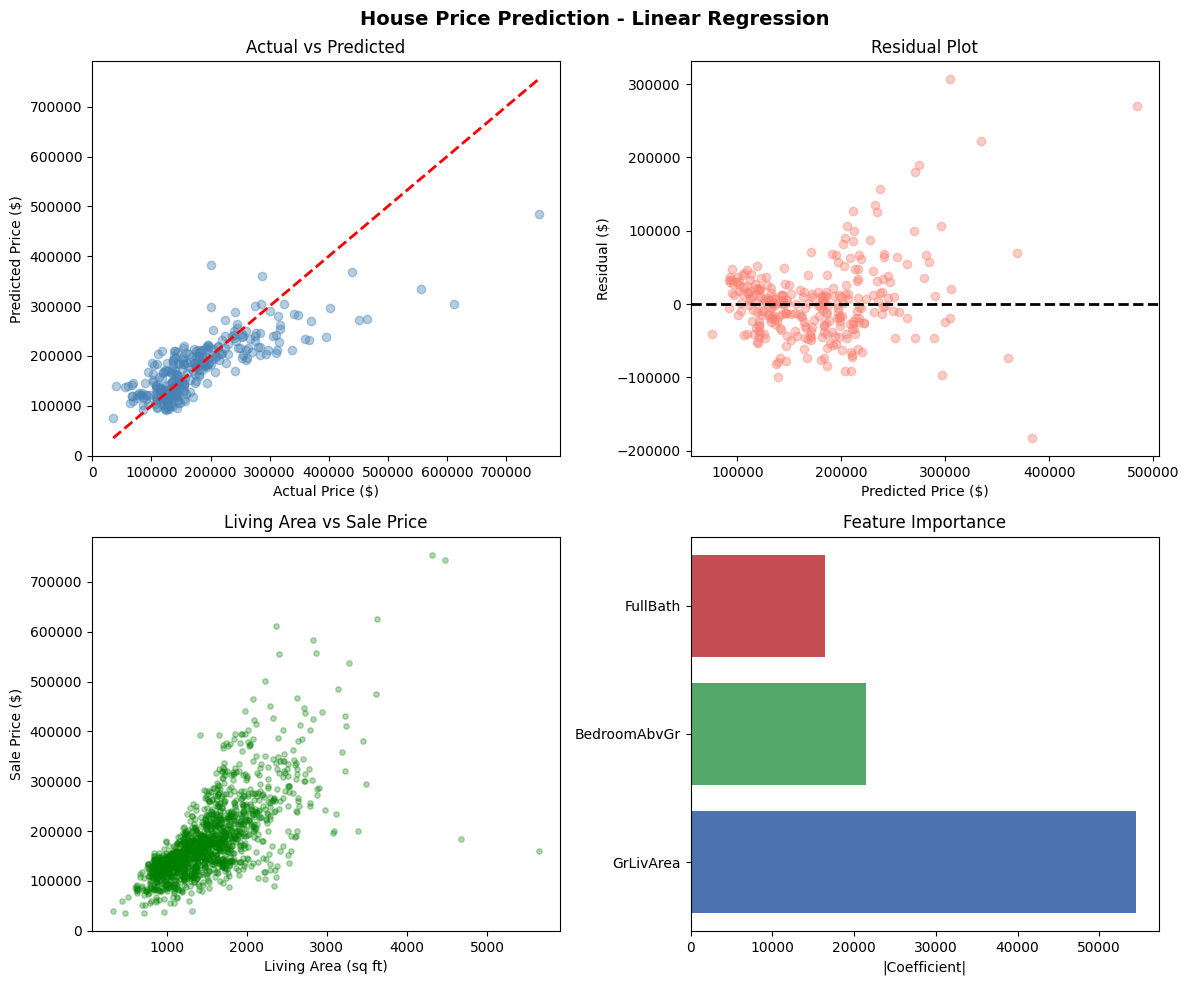

✅ Chart saved as results.png!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('House Price Prediction - Linear Regression', fontsize=14, fontweight='bold')

# 1. Actual vs Predicted
axes[0,0].scatter(y_test, y_pred, alpha=0.4, color='steelblue')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Price ($)')
axes[0,0].set_ylabel('Predicted Price ($)')
axes[0,0].set_title('Actual vs Predicted')

# 2. Residuals
residuals = y_test - y_pred
axes[0,1].scatter(y_pred, residuals, alpha=0.4, color='salmon')
axes[0,1].axhline(0, color='black', lw=2, linestyle='--')
axes[0,1].set_xlabel('Predicted Price ($)')
axes[0,1].set_ylabel('Residual ($)')
axes[0,1].set_title('Residual Plot')

# 3. Living Area vs Price
axes[1,0].scatter(data['GrLivArea'], data['SalePrice'], alpha=0.3, color='green', s=15)
axes[1,0].set_xlabel('Living Area (sq ft)')
axes[1,0].set_ylabel('Sale Price ($)')
axes[1,0].set_title('Living Area vs Sale Price')

# 4. Feature Importance
importance = np.abs(model.coef_)
axes[1,1].barh(FEATURES, importance, color=['#4C72B0','#55A868','#C44E52'])
axes[1,1].set_xlabel('|Coefficient|')
axes[1,1].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as results.png!")